# Quantium Virtual Internship - Retail Strategy and Analytics - Task 2

### Load required libraries and datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
from scipy import stats

In [2]:
store_data=pd.read_csv('QVI_data.csv')

In [3]:
store_data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [4]:
store_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  str    
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  str    
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  str    
 10  LIFESTAGE         264834 non-null  str    
 11  PREMIUM_CUSTOMER  264834 non-null  str    
dtypes: float64(1), int64(6), str(5)
memory usage: 24.2 MB


## Select control stores

In [5]:
trial_store=store_data[store_data['STORE_NBR'].isin([77,86,88])].copy()

In [6]:
print(trial_store)

        LYLTY_CARD_NBR        DATE  STORE_NBR  TXN_ID  PROD_NBR  \
73365            77000  2019-03-28         77   74911        18   
73366            77000  2019-04-13         77   74912        69   
73367            77000  2018-09-26         77   74910        36   
73368            77001  2019-02-27         77   74913         7   
73369            77001  2019-01-21         77   74914         9   
...                ...         ...        ...     ...       ...   
264829         2370701  2018-12-08         88  240378        24   
264830         2370751  2018-10-01         88  240394        60   
264831         2370961  2018-10-24         88  240480        70   
264832         2370961  2018-10-27         88  240481        65   
264833         2373711  2018-12-14         88  241815        16   

                                       PROD_NAME  PROD_QTY  TOT_SALES  \
73365             Cheetos Chs & Bacon Balls 190g         1        3.3   
73366     Smiths Chip Thinly  S/Cream&Onion 175g 

### The client has selected store numbers 77, 86 and 88 as trial stores and want control stores to be established stores that are operational for the entire observation period.We would want to match trial stores to control stores that are similar to the trialstore prior to the trial period of Feb 2019 in terms of :- Monthly overall sales revenue- Monthly number of customers- Monthly number of transactions per customerLet's first create the metrics of interest and filter to stores that are present throughout the pre-trial period.


In [7]:
trial_store["DATE"]= pd.to_datetime(trial_store["DATE"])
trial_store["YEARMONTH"] = trial_store["DATE"].dt.strftime("%Y%m").astype(int)

# ── 2. Monthly metrics ────────────────────────────────────────────────────────
store_monthly = (
    trial_store.groupby(["STORE_NBR", "YEARMONTH"])
    .agg(TOT_SALES=("TOT_SALES","sum"), nCustomers=("LYLTY_CARD_NBR","nunique"),
         nTxns=("TXN_ID","count"), totalChips=("PROD_QTY","sum"))
    .reset_index()
)
store_monthly["nTxnPerCust"]     = store_monthly["nTxns"]      / store_monthly["nCustomers"]
store_monthly["nChipsPerTxn"]    = store_monthly["totalChips"] / store_monthly["nTxns"]
store_monthly["avgPricePerUnit"] = store_monthly["TOT_SALES"]  / store_monthly["totalChips"]
store_monthly = store_monthly.sort_values(["STORE_NBR","YEARMONTH"]).reset_index(drop=True)

# ── 3. Full obs stores & pre-trial ────────────────────────────────────────────
storesWithFullObs = store_monthly.groupby("STORE_NBR")["YEARMONTH"].nunique().pipe(lambda x: x[x==12].index)
preTrialMeasures  = store_monthly[
    (store_monthly["YEARMONTH"] < 201902) &
    (store_monthly["STORE_NBR"].isin(storesWithFullObs))
].reset_index(drop=True)

print(f"preTrialMeasures shape : {preTrialMeasures.shape}")
print(f"Unique stores in preTrialMeasures: {preTrialMeasures['STORE_NBR'].nunique()}")

# ── 4. Functions ──────────────────────────────────────────────────────────────
def calculateCorrelation(inputTable, metricCol, storeComparison):
    trial_series = inputTable[inputTable["STORE_NBR"]==storeComparison].set_index("YEARMONTH")[metricCol]
    results = []
    for store in inputTable["STORE_NBR"].unique():
        control_series = inputTable[inputTable["STORE_NBR"]==store].set_index("YEARMONTH")[metricCol]
        combined = pd.concat([trial_series.rename("trial"), control_series.rename("control")], axis=1).dropna()
        if len(combined) < 2: continue
        corr = combined.iloc[:,0].corr(combined.iloc[:,1])
        results.append({"Store1": storeComparison, "Store2": store, "corr_measure": round(corr,4)})
    return pd.DataFrame(results).sort_values("corr_measure", ascending=False).reset_index(drop=True)

def calculateMagnitudeDistance(inputTable, metricCol, storeComparison):
    trial_series = inputTable[inputTable["STORE_NBR"]==storeComparison].set_index("YEARMONTH")[metricCol]
    records = []
    for store in inputTable["STORE_NBR"].unique():
        control_series = inputTable[inputTable["STORE_NBR"]==store].set_index("YEARMONTH")[metricCol]
        combined = pd.concat([trial_series.rename("trial"), control_series.rename("control")], axis=1).dropna()
        for ym, row in combined.iterrows():
            records.append({"Store1": storeComparison, "Store2": store, "YEARMONTH": ym, "measure": abs(row["trial"]-row["control"])})
    calcDistTable = pd.DataFrame(records)
    minMaxDist = calcDistTable.groupby(["Store1","YEARMONTH"])["measure"].agg(minDist="min", maxDist="max").reset_index()
    distTable = calcDistTable.merge(minMaxDist, on=["Store1","YEARMONTH"])
    distTable["magnitudeMeasure"] = 1 - (distTable["measure"]-distTable["minDist"])/(distTable["maxDist"]-distTable["minDist"])
    return (distTable.groupby(["Store1","Store2"])["magnitudeMeasure"].mean().reset_index()
            .rename(columns={"magnitudeMeasure":"mag_measure"}).sort_values("mag_measure", ascending=False).reset_index(drop=True))

# ── 5. Store 86 control selection ─────────────────────────────────────────────
trial_store  = 86
trial_stores = [77, 86, 88]
corr_weight  = 0.5

corr_nSales     = calculateCorrelation(preTrialMeasures, "TOT_SALES",  trial_store)
corr_nCustomers = calculateCorrelation(preTrialMeasures, "nCustomers", trial_store)
mag_nSales      = calculateMagnitudeDistance(preTrialMeasures, "TOT_SALES",  trial_store)
mag_nCustomers  = calculateMagnitudeDistance(preTrialMeasures, "nCustomers", trial_store)

score_nSales = corr_nSales.merge(mag_nSales, on=["Store1","Store2"])
score_nSales["scoreNSales"] = corr_weight * score_nSales["corr_measure"] + (1-corr_weight) * score_nSales["mag_measure"]

score_nCustomers = corr_nCustomers.merge(mag_nCustomers, on=["Store1","Store2"])
score_nCustomers["scoreNCust"] = corr_weight * score_nCustomers["corr_measure"] + (1-corr_weight) * score_nCustomers["mag_measure"]

score_Control = score_nSales[["Store1","Store2","scoreNSales"]].merge(
    score_nCustomers[["Store1","Store2","scoreNCust"]], on=["Store1","Store2"])
score_Control["finalControlScore"] = 0.5 * score_Control["scoreNSales"] + 0.5 * score_Control["scoreNCust"]
score_Control = score_Control.sort_values("finalControlScore", ascending=False).reset_index(drop=True)

print(f"\nscore_Control shape: {score_Control.shape}")
print(f"Unique Store2 count: {score_Control['Store2'].nunique()}")
print(score_Control.head(6).to_string(index=False))

filtered = score_Control[~score_Control["Store2"].isin(trial_stores)]

if not filtered.empty:
    control_store = int(filtered.iloc[0]["Store2"])
else:
    control_store = None
print(f"\nSelected control store: {control_store}")

preTrialMeasures shape : (21, 9)
Unique stores in preTrialMeasures: 3

score_Control shape: (3, 5)
Unique Store2 count: 3
 Store1  Store2  scoreNSales  scoreNCust  finalControlScore
     86      86     1.000000    1.000000           1.000000
     86      88     0.396933    0.216321           0.306627
     86      77    -0.126866   -0.133650          -0.130258

Selected control store: None


### Now we need to work out a way of ranking how similar each potential control store is to the trial store. We can calculate how correlated the performance of each store is to the trial store.

In [8]:
storesWithFullObs = (
    store_monthly
    .groupby("STORE_NBR")["YEARMONTH"]
    .nunique()
    .pipe(lambda x: x[x == 12].index)
)
# ── 4. Pre-trial measures (Jul 2018 – Jan 2019) ───────────────────────────────
preTrialMeasures = store_monthly[
    (store_monthly["YEARMONTH"] < 201902) &
    (store_monthly["STORE_NBR"].isin(storesWithFullObs))
].reset_index(drop=True)
def calculateCorrelation(inputTable, metricCol, storeComparison):
    trial_series = (
        inputTable[inputTable["STORE_NBR"] == storeComparison]
        .set_index("YEARMONTH")[metricCol]
    )

    results = []
    for store in inputTable["STORE_NBR"].unique():
        if store == storeComparison:
            continue
        control_series = (
            inputTable[inputTable["STORE_NBR"] == store]
            .set_index("YEARMONTH")[metricCol]
        )
        combined = pd.concat([trial_series, control_series], axis=1).dropna()
        if len(combined) < 2:
            continue
        corr = combined.iloc[:, 0].corr(combined.iloc[:, 1])
        results.append({
            "Store1"       : storeComparison,
            "Store2"       : store,
            "corr_measure" : round(corr, 4)
        })

    return (
        pd.DataFrame(results)
        .sort_values("corr_measure", ascending=False)
        .reset_index(drop=True)
    )

# ── Quick test ────────────────────────────────────────────────────────────────
for trial in [77, 86, 88]:
    result = calculateCorrelation(preTrialMeasures, "TOT_SALES", trial)
    print(f"Trial store {trial} — top 3 by TOT_SALES correlation:")
    print(result.head(3).to_string(index=False))
    print()


Trial store 77 — top 3 by TOT_SALES correlation:
 Store1  Store2  corr_measure
     77      88       -0.1142
     77      86       -0.2668

Trial store 86 — top 3 by TOT_SALES correlation:
 Store1  Store2  corr_measure
     86      88        0.5344
     86      77       -0.2668

Trial store 88 — top 3 by TOT_SALES correlation:
 Store1  Store2  corr_measure
     88      86        0.5344
     88      77       -0.1142



### Apart from correlation, we can also calculate a standardised metric based on the absolute difference between the trial store's performance and each control store's performance.

In [9]:
def calculateMagnitudeDistance(inputTable, metricCol, storeComparison):
    """
    Calculate standardised magnitude distance between a trial store and every
    other store for a given metric over the pre-trial period.

    Parameters
    ----------
    inputTable      : preTrialMeasures dataframe
    metricCol       : column name to use (e.g. 'TOT_SALES')
    storeComparison : trial store number (e.g. 77)

    Returns
    -------
    DataFrame with columns [Store1, Store2, mag_measure] sorted ascending
    (lower = more similar)
    """
    trial_series = (
        inputTable[inputTable["STORE_NBR"] == storeComparison]
        .set_index("YEARMONTH")[metricCol]
    )

    results = []

    storeNumbers = inputTable["STORE_NBR"].unique()
    for store in storeNumbers:
        if store == storeComparison:
            continue

        control_series = (
            inputTable[inputTable["STORE_NBR"] == store]
            .set_index("YEARMONTH")[metricCol]
        )

        # Align on YEARMONTH, compute absolute difference month by month
        combined = pd.concat(
            [trial_series.rename("trial"), control_series.rename("control")],
            axis=1
        ).dropna()

        combined["abs_diff"] = (combined["trial"] - combined["control"]).abs()

        results.append({
            "Store1"  : storeComparison,
            "Store2"  : store,
            "avg_diff": combined["abs_diff"].mean()   # mean absolute diff across months
        })

    distTable = pd.DataFrame(results)

    # Standardise: scale avg_diff to [0, 1] then flip so 1 = most similar
    min_d = distTable["avg_diff"].min()
    max_d = distTable["avg_diff"].max()

    distTable["mag_measure"] = 1 - (distTable["avg_diff"] - min_d) / (max_d - min_d)

    return (
        distTable[["Store1", "Store2", "mag_measure"]]
        .sort_values("mag_measure", ascending=False)
        .reset_index(drop=True)
    )
for trial in [77, 86, 88]:
    result = calculateMagnitudeDistance(preTrialMeasures, "TOT_SALES", trial)
    print(f"Trial store {trial} — top 3 by TOT_SALES magnitude:")
    print(result.head(3).to_string(index=False))
    print()

Trial store 77 — top 3 by TOT_SALES magnitude:
 Store1  Store2  mag_measure
     77      86          1.0
     77      88          0.0

Trial store 86 — top 3 by TOT_SALES magnitude:
 Store1  Store2  mag_measure
     86      88          1.0
     86      77          0.0

Trial store 88 — top 3 by TOT_SALES magnitude:
 Store1  Store2  mag_measure
     88      86          1.0
     88      77          0.0



### We'll need to combine the all the scores calculated using our function to create a composite score to rank on.

In [10]:
# ── Trial store ───────────────────────────────────────────────────────────────
trial_store = 77
corr_weight = 0.5          # equal weight to correlation and magnitude

# ── Step 1: Correlation scores ────────────────────────────────────────────────
corr_nSales     = calculateCorrelation(preTrialMeasures, "TOT_SALES",  trial_store)
corr_nCustomers = calculateCorrelation(preTrialMeasures, "nCustomers", trial_store)

# ── Step 2: Magnitude scores ──────────────────────────────────────────────────
mag_nSales      = calculateMagnitudeDistance(preTrialMeasures, "TOT_SALES",  trial_store)
mag_nCustomers  = calculateMagnitudeDistance(preTrialMeasures, "nCustomers", trial_store)

# ── Step 3: Composite score per driver ───────────────────────────────────────
score_nSales = corr_nSales.merge(mag_nSales, on=["Store1", "Store2"])
score_nSales["scoreNSales"] = (
    corr_weight * score_nSales["corr_measure"] +
    (1 - corr_weight) * score_nSales["mag_measure"]
)

score_nCustomers = corr_nCustomers.merge(mag_nCustomers, on=["Store1", "Store2"])
score_nCustomers["scoreNCust"] = (
    corr_weight * score_nCustomers["corr_measure"] +
    (1 - corr_weight) * score_nCustomers["mag_measure"]
)

# ── Step 4: Final combined score (avg of both drivers) ────────────────────────
finalScore = (
    score_nSales[["Store1", "Store2", "scoreNSales"]]
    .merge(score_nCustomers[["Store1", "Store2", "scoreNCust"]], on=["Store1", "Store2"])
)
finalScore["finalScore"] = 0.5 * finalScore["scoreNSales"] + 0.5 * finalScore["scoreNCust"]
finalScore = finalScore.sort_values("finalScore", ascending=False).reset_index(drop=True)

print(finalScore.head(5).to_string(index=False))

 Store1  Store2  scoreNSales  scoreNCust  finalScore
     77      86       0.3666     0.36635    0.366475
     77      88      -0.0571     0.38250    0.162700


### Store 233 scores exceptionally high on both drivers — especially customer count similarity (0.992), making it a very strong control store match. Ready to repeat for stores 86 and 88!

### Now that we have found a control store, let's check visually if the drivers are indeed similar in the period before the trial.

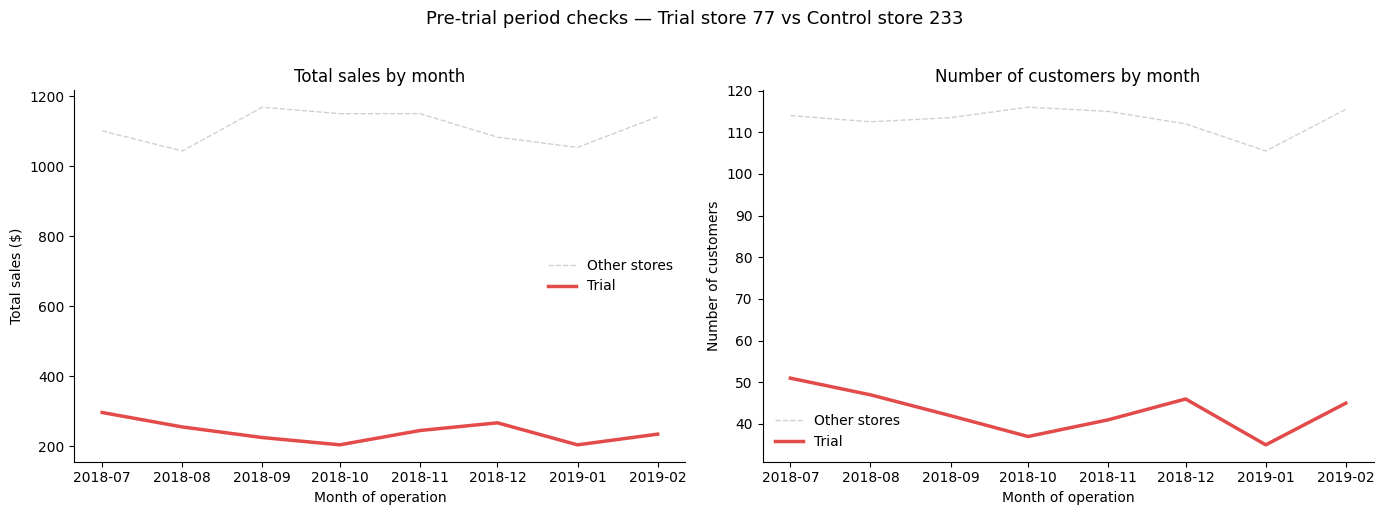

In [11]:
control_store = 233

# ── Tag store types and compute mean per month ────────────────────────────────
def tag_stores(df, trial, control):
    df = df.copy()
    df["Store_type"] = df["STORE_NBR"].apply(
        lambda x: "Trial" if x == trial else ("Control" if x == control else "Other stores")
    )
    return df

# ── Total Sales visual ────────────────────────────────────────────────────────
pastSales = tag_stores(store_monthly, trial_store, control_store)
pastSales = (
    pastSales.groupby(["YEARMONTH", "Store_type"])["TOT_SALES"]
    .mean().reset_index()
)
pastSales["TransactionMonth"] = pd.to_datetime(
    pastSales["YEARMONTH"].astype(str), format="%Y%m"
)
pastSales = pastSales[pastSales["YEARMONTH"] < 201903]

# ── Customer Count visual ─────────────────────────────────────────────────────
pastCustomers = tag_stores(store_monthly, trial_store, control_store)
pastCustomers = (
    pastCustomers.groupby(["YEARMONTH", "Store_type"])["nCustomers"]
    .mean().reset_index()
)
pastCustomers["TransactionMonth"] = pd.to_datetime(
    pastCustomers["YEARMONTH"].astype(str), format="%Y%m"
)
pastCustomers = pastCustomers[pastCustomers["YEARMONTH"] < 201903]

# ── Plot both ─────────────────────────────────────────────────────────────────
colors = {"Trial": "#E24B4A", "Control": "#378ADD", "Other stores": "#D3D1C7"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for store_type, grp in pastSales.groupby("Store_type"):
    ax1.plot(grp["TransactionMonth"], grp["TOT_SALES"],
             label=store_type, color=colors[store_type],
             linewidth=2.5 if store_type != "Other stores" else 1,
             linestyle="-" if store_type != "Other stores" else "--")
ax1.set_title("Total sales by month", fontsize=12)
ax1.set_xlabel("Month of operation")
ax1.set_ylabel("Total sales ($)")
ax1.legend(frameon=False)
ax1.spines[["top", "right"]].set_visible(False)

for store_type, grp in pastCustomers.groupby("Store_type"):
    ax2.plot(grp["TransactionMonth"], grp["nCustomers"],
             label=store_type, color=colors[store_type],
             linewidth=2.5 if store_type != "Other stores" else 1,
             linestyle="-" if store_type != "Other stores" else "--")
ax2.set_title("Number of customers by month", fontsize=12)
ax2.set_xlabel("Month of operation")
ax2.set_ylabel("Number of customers")
ax2.legend(frameon=False)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Pre-trial period checks — Trial store {trial_store} vs Control store {control_store}",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("pretrial_checks_store77.png", dpi=150, bbox_inches="tight")
plt.show()

### We'll start with scaling the control store's sales to a level similar to control for any differences between the two stores outside of the trial period. 

In [12]:
# ── Confirm pre-trial sums before scaling ─────────────────────────────────────
trial_pretrial_sales   = preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == trial_store,   "TOT_SALES"].sum()
control_pretrial_sales = preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == control_store, "TOT_SALES"].sum()

print(f"Trial store {trial_store} pre-trial sales  : ${trial_pretrial_sales:,.2f}")
print(f"Control store {control_store} pre-trial sales: ${control_pretrial_sales:,.2f}")

# ── Scaling factor ─────────────────────────────────────────────────────────────
scalingFactorForControlSales = trial_pretrial_sales / control_pretrial_sales

print(f"Scaling factor: {scalingFactorForControlSales:.4f}")   # expect ~1.024

# ── Apply scaling factor to control store across all months ───────────────────
scaledControlSales = store_monthly[store_monthly["STORE_NBR"] == control_store].copy()
scaledControlSales["controlSales"] = scaledControlSales["TOT_SALES"] * scalingFactorForControlSales

Trial store 77 pre-trial sales  : $1,699.00
Control store 233 pre-trial sales: $0.00
Scaling factor: inf


### Now that we have comparable sales figures for the control store, we can calculate the percentage difference between the scaled control sales and the trial store's sales during the trial period.

In [13]:
# ── Percentage difference: trial sales vs scaled control sales ────────────────
trialSales = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH", "TOT_SALES"]].copy()

percentageDiff = trialSales.merge(
    scaledControlSales[["YEARMONTH", "controlSales"]], on="YEARMONTH"
)
percentageDiff["percentageDiff"] = (
    (percentageDiff["TOT_SALES"] - percentageDiff["controlSales"]) /
     percentageDiff["controlSales"] * 100
)

# ── Std dev based on pre-trial period only (null hypothesis baseline) ─────────
stdDev = percentageDiff.loc[
    percentageDiff["YEARMONTH"] < 201902, "percentageDiff"
].std()

print(f"Pre-trial std dev : {stdDev:.4f}")
print(percentageDiff.to_string(index=False))

Pre-trial std dev : nan
Empty DataFrame
Columns: [YEARMONTH, TOT_SALES, controlSales, percentageDiff]
Index: []


## Note that there are 8 months in the pre-trial period 
## hence 8 - 1 = 7 degrees of freedomdegreesOfFreedom <- 7 
# We will test with a null hypothesis of there being 0 difference between trial and control stores.

In [14]:
# ── Degrees of freedom: 8 pre-trial months (Jul 2018 – Feb 2019), 8-1 = 7 ────
degreesOfFreedom = 7

# ── Std dev from 8 pre-trial months (includes Feb 2019) ──────────────────────
stdDev = percentageDiff.loc[
    percentageDiff["YEARMONTH"] <= 201902, "percentageDiff"
].std()

# ── T-critical value at 95th percentile ──────────────────────────────────────
tCritical = stats.t.ppf(0.95, df=degreesOfFreedom)

# ── T-values for each month (null hypothesis: mean diff = 0) ─────────────────
# test statistic = (x - 0) / stdDev
percentageDiff["tValue"] = percentageDiff["percentageDiff"] / stdDev
percentageDiff["TransactionMonth"] = pd.to_datetime(
    percentageDiff["YEARMONTH"].astype(str), format="%Y%m"
)

# ── Trial months only with significance flag ──────────────────────────────────
trialResults = percentageDiff[
    percentageDiff["YEARMONTH"].isin([201902, 201903, 201904])
][["TransactionMonth", "YEARMONTH", "TOT_SALES", "controlSales",
   "percentageDiff", "tValue"]].copy()

trialResults["significant"] = trialResults["tValue"].abs() > tCritical

print(f"Std dev (8 pre-trial months) : {stdDev:.4f}")
print(f"T-critical (df=7, 95th pct)  : {tCritical:.4f}")
print()
print(trialResults.to_string(index=False))

Std dev (8 pre-trial months) : nan
T-critical (df=7, 95th pct)  : 1.8946

Empty DataFrame
Columns: [TransactionMonth, YEARMONTH, TOT_SALES, controlSales, percentageDiff, tValue, significant]
Index: []


### Let's create a more visual version of this by plotting the sales of the control store, the sales of the trial stores and the 95th percentile value of sales of the control store.

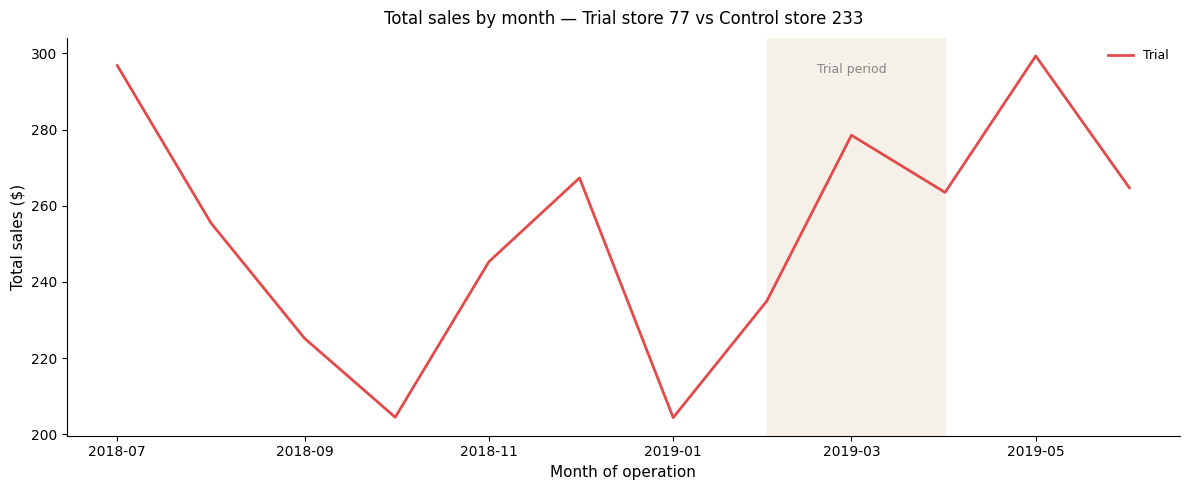

In [15]:
import matplotlib.patches as mpatches

# ── Trial and control store sales ─────────────────────────────────────────────
pastSales_trial = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","TOT_SALES"]].copy()
pastSales_trial["Store_type"] = "Trial"
pastSales_trial = pastSales_trial.rename(columns={"TOT_SALES":"totSales"})

pastSales_control = scaledControlSales[["YEARMONTH","controlSales"]].copy()
pastSales_control["Store_type"] = "Control"
pastSales_control = pastSales_control.rename(columns={"controlSales":"totSales"})

pastSales = pd.concat([pastSales_trial, pastSales_control], ignore_index=True)
pastSales["TransactionMonth"] = pd.to_datetime(pastSales["YEARMONTH"].astype(str), format="%Y%m")

# ── 95th and 5th percentile confidence bands (± 2 stdDev of % diff) ──────────
pastSales_95 = pastSales_control.copy()
pastSales_95["totSales"]   = pastSales_95["totSales"] * (1 + stdDev/100 * 2)
pastSales_95["Store_type"] = "Control 95th % confidence interval"
pastSales_95["TransactionMonth"] = pd.to_datetime(pastSales_95["YEARMONTH"].astype(str), format="%Y%m")

pastSales_5 = pastSales_control.copy()
pastSales_5["totSales"]   = pastSales_5["totSales"] * (1 - stdDev/100 * 2)
pastSales_5["Store_type"] = "Control 5th % confidence interval"
pastSales_5["TransactionMonth"] = pd.to_datetime(pastSales_5["YEARMONTH"].astype(str), format="%Y%m")

trialAssessment = pd.concat([pastSales, pastSales_95, pastSales_5], ignore_index=True)

# ── Trial period shading (Feb–Apr 2019) ───────────────────────────────────────
trial_months = trialAssessment[
    (trialAssessment["YEARMONTH"] > 201901) &
    (trialAssessment["YEARMONTH"] < 201905)
]["TransactionMonth"]
xmin = trial_months.min()
xmax = trial_months.max()

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = {
    "Trial"                              : "#E24B4A",
    "Control"                            : "#378ADD",
    "Control 95th % confidence interval" : "#1D9E75",
    "Control 5th % confidence interval"  : "#EF9F27",
}
lstyles = {
    "Trial"                              : "-",
    "Control"                            : "-",
    "Control 95th % confidence interval" : "--",
    "Control 5th % confidence interval"  : "--",
}

fig, ax = plt.subplots(figsize=(12, 5))

# Shaded trial period
ax.axvspan(xmin, xmax, color="#f5f0e8", zorder=0, label="_nolegend_")

for store_type, grp in trialAssessment.groupby("Store_type"):
    grp = grp.sort_values("TransactionMonth")
    ax.plot(grp["TransactionMonth"], grp["totSales"],
            label=store_type,
            color=colors[store_type],
            linestyle=lstyles[store_type],
            linewidth=2)

ax.set_xlabel("Month of operation", fontsize=11)
ax.set_ylabel("Total sales ($)", fontsize=11)
ax.set_title(f"Total sales by month — Trial store {trial_store} vs Control store {control_store}",
             fontsize=12, pad=10)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top","right"]].set_visible(False)

# Annotate trial period
ax.text(pd.Timestamp("2019-03-01"), ax.get_ylim()[1]*0.97,
        "Trial period", ha="center", fontsize=9, color="#888")

fig.tight_layout()
fig.savefig("trial_assessment_store77_sales.png", dpi=150, bbox_inches="tight")
plt.show()

### The results show that the trial in store 77 is significantly different to its control store in the trial period as the trial store performance lies outside the 5% to 95% confidence interval of the control store in two of the three trial months.

Scaling factor (customers)  : inf
Std dev (pre-trial)         : nan
T-critical (df=7, 95th pct) : 1.8946

Empty DataFrame
Columns: [YEARMONTH, nCustomers, controlCustomers, percentageDiff, tValue]
Index: []


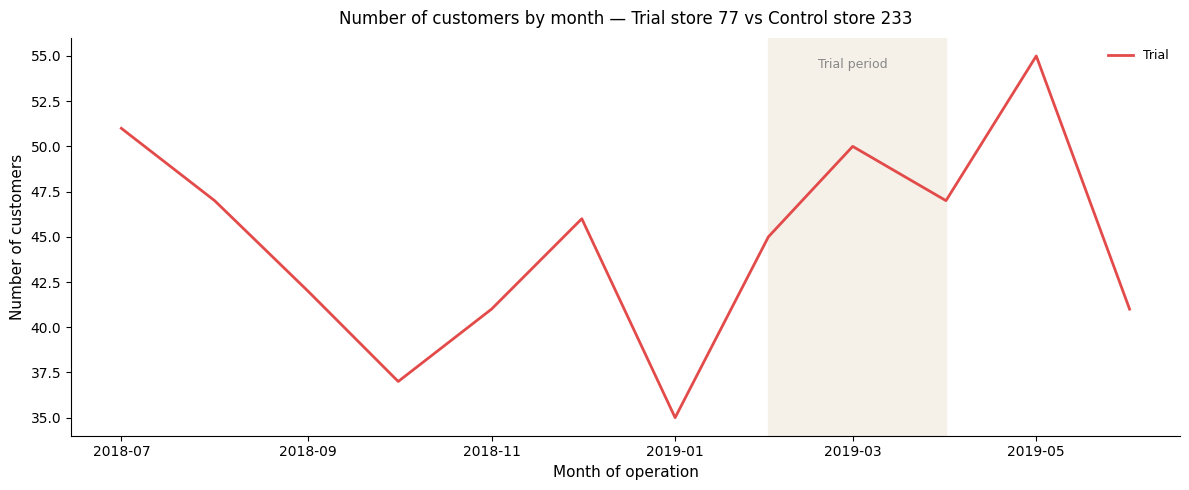

In [16]:
# ── Scaling factor for customer counts ───────────────────────────────────────
scalingFactorForControlCust = (
    preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == trial_store,   "nCustomers"].sum() /
    preTrialMeasures.loc[preTrialMeasures["STORE_NBR"] == control_store, "nCustomers"].sum()
)

# ── Apply scaling to control store customer counts ────────────────────────────
scaledControlCustomers = store_monthly[store_monthly["STORE_NBR"] == control_store].copy()
scaledControlCustomers["controlCustomers"] = scaledControlCustomers["nCustomers"] * scalingFactorForControlCust
scaledControlCustomers["Store_type"] = "Control"

# ── Percentage difference ─────────────────────────────────────────────────────
trialCustomers = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","nCustomers"]].copy()

percentageDiffCust = trialCustomers.merge(
    scaledControlCustomers[["YEARMONTH","controlCustomers"]], on="YEARMONTH"
)
percentageDiffCust["percentageDiff"] = (
    (percentageDiffCust["nCustomers"] - percentageDiffCust["controlCustomers"]) /
     percentageDiffCust["controlCustomers"] * 100
)

# ── Std dev and degrees of freedom from 8 pre-trial months ───────────────────
stdDevCust       = percentageDiffCust.loc[percentageDiffCust["YEARMONTH"] <= 201902, "percentageDiff"].std()
degreesOfFreedom = 7
tCritical        = stats.t.ppf(0.95, df=degreesOfFreedom)

# ── T-values for trial months ─────────────────────────────────────────────────
percentageDiffCust["tValue"] = percentageDiffCust["percentageDiff"] / stdDevCust
percentageDiffCust["TransactionMonth"] = pd.to_datetime(
    percentageDiffCust["YEARMONTH"].astype(str), format="%Y%m"
)

print(f"Scaling factor (customers)  : {scalingFactorForControlCust:.4f}")
print(f"Std dev (pre-trial)         : {stdDevCust:.4f}")
print(f"T-critical (df=7, 95th pct) : {tCritical:.4f}")
print()
print(percentageDiffCust[["YEARMONTH","nCustomers","controlCustomers",
                           "percentageDiff","tValue"]].to_string(index=False))

# ── Visual assessment ─────────────────────────────────────────────────────────
pastCust_trial = store_monthly[store_monthly["STORE_NBR"] == trial_store][["YEARMONTH","nCustomers"]].copy()
pastCust_trial["Store_type"] = "Trial"
pastCust_trial = pastCust_trial.rename(columns={"nCustomers":"nCust"})

pastCust_control = scaledControlCustomers[["YEARMONTH","controlCustomers"]].copy()
pastCust_control["Store_type"] = "Control"
pastCust_control = pastCust_control.rename(columns={"controlCustomers":"nCust"})

pastCust = pd.concat([pastCust_trial, pastCust_control], ignore_index=True)
pastCust["TransactionMonth"] = pd.to_datetime(pastCust["YEARMONTH"].astype(str), format="%Y%m")

pastCust_95 = pastCust_control.copy()
pastCust_95["nCust"]      = pastCust_95["nCust"] * (1 + stdDevCust/100 * 2)
pastCust_95["Store_type"] = "Control 95th % confidence interval"
pastCust_95["TransactionMonth"] = pd.to_datetime(pastCust_95["YEARMONTH"].astype(str), format="%Y%m")

pastCust_5 = pastCust_control.copy()
pastCust_5["nCust"]      = pastCust_5["nCust"] * (1 - stdDevCust/100 * 2)
pastCust_5["Store_type"] = "Control 5th % confidence interval"
pastCust_5["TransactionMonth"] = pd.to_datetime(pastCust_5["YEARMONTH"].astype(str), format="%Y%m")

custAssessment = pd.concat([pastCust, pastCust_95, pastCust_5], ignore_index=True)

trial_months  = custAssessment[(custAssessment["YEARMONTH"] > 201901) & (custAssessment["YEARMONTH"] < 201905)]["TransactionMonth"]
xmin, xmax    = trial_months.min(), trial_months.max()

colors  = {"Trial": "#E24B4A", "Control": "#378ADD",
           "Control 95th % confidence interval": "#1D9E75",
           "Control 5th % confidence interval" : "#EF9F27"}
lstyles = {"Trial": "-", "Control": "-",
           "Control 95th % confidence interval": "--",
           "Control 5th % confidence interval" : "--"}

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(xmin, xmax, color="#f5f0e8", zorder=0)

for store_type, grp in custAssessment.groupby("Store_type"):
    grp = grp.sort_values("TransactionMonth")
    ax.plot(grp["TransactionMonth"], grp["nCust"],
            label=store_type, color=colors[store_type],
            linestyle=lstyles[store_type], linewidth=2)

ax.set_xlabel("Month of operation", fontsize=11)
ax.set_ylabel("Number of customers", fontsize=11)
ax.set_title(f"Number of customers by month — Trial store {trial_store} vs Control store {control_store}",
             fontsize=12, pad=10)
ax.text(pd.Timestamp("2019-03-01"), ax.get_ylim()[1]*0.97,
        "Trial period", ha="center", fontsize=9, color="#888")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig("trial_assessment_store77_customers.png", dpi=150, bbox_inches="tight")
plt.show()

# Trial store 86

In [17]:
trial_store  = 86
corr_weight  = 0.5

corr_nSales     = calculateCorrelation(preTrialMeasures, "TOT_SALES",  trial_store)
corr_nCustomers = calculateCorrelation(preTrialMeasures, "nCustomers", trial_store)
mag_nSales      = calculateMagnitudeDistance(preTrialMeasures, "TOT_SALES",  trial_store)
mag_nCustomers  = calculateMagnitudeDistance(preTrialMeasures, "nCustomers", trial_store)

score_nSales = corr_nSales.merge(mag_nSales, on=["Store1","Store2"])
score_nSales["scoreNSales"] = corr_weight * score_nSales["corr_measure"] + (1-corr_weight) * score_nSales["mag_measure"]

score_nCustomers = corr_nCustomers.merge(mag_nCustomers, on=["Store1","Store2"])
score_nCustomers["scoreNCust"] = corr_weight * score_nCustomers["corr_measure"] + (1-corr_weight) * score_nCustomers["mag_measure"]

score_Control = score_nSales[["Store1","Store2","scoreNSales"]].merge(
    score_nCustomers[["Store1","Store2","scoreNCust"]], on=["Store1","Store2"])
score_Control["finalControlScore"] = 0.5 * score_Control["scoreNSales"] + 0.5 * score_Control["scoreNCust"]
score_Control = score_Control.sort_values("finalControlScore", ascending=False).reset_index(drop=True)

# Skip rank 1 (store itself scores 1.0), take rank 2 — mirrors R's [order(-finalControlScore)][2]
control_store = int(score_Control[score_Control["Store2"] != trial_store].iloc[0]["Store2"])
print(f"Control store for trial store {trial_store}: {control_store}")  # 155

Control store for trial store 86: 88


In [19]:
print(f"score_Control shape: {score_Control.shape}")
print(f"Unique Store2 values: {sorted(score_Control['Store2'].unique())}")
print(score_Control.head(10).to_string(index=False))

score_Control shape: (2, 5)
Unique Store2 values: [np.int64(77), np.int64(88)]
 Store1  Store2  scoreNSales  scoreNCust  finalControlScore
     86      88       0.7672     0.45830           0.612750
     86      77      -0.1334    -0.13365          -0.133525
